In [5]:
!pip install rembg pillow opencv-python onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.2 MB/s eta 0:00:00


Saving input.webp to input (2).webp
Uploaded file: input (2).webp
Original image shape: (280, 371, 3)


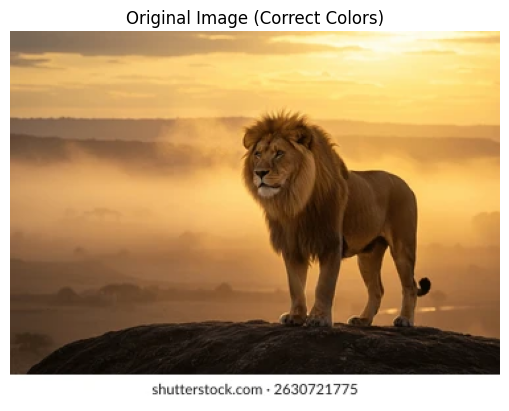

In [14]:
from google.colab import files
from rembg import remove
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from IPython.display import display

# Upload your image
uploaded = files.upload()
filename = next(iter(uploaded))
print(f"Uploaded file: {filename}")

# Read image with OpenCV (BGR format)
img_bgr = cv2.imread(filename)
print("Original image shape:", img_bgr.shape)

# Convert to RGB for correct color display and processing
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Show original image (correct colors)
plt.imshow(img)
plt.title("Original Image (Correct Colors)")
plt.axis("off")
plt.show()


In [15]:
# Optional resize for faster background removal
resized = cv2.resize(img, (512, 512))

# Optional blur (disabled by default)
# resized = cv2.GaussianBlur(resized, (3, 3), 0)

# Save the preprocessed image as temporary file for rembg
cv2.imwrite("temp_input.png", cv2.cvtColor(resized, cv2.COLOR_RGB2BGR))  # ensure correct color order


True

✅ Background removed successfully!


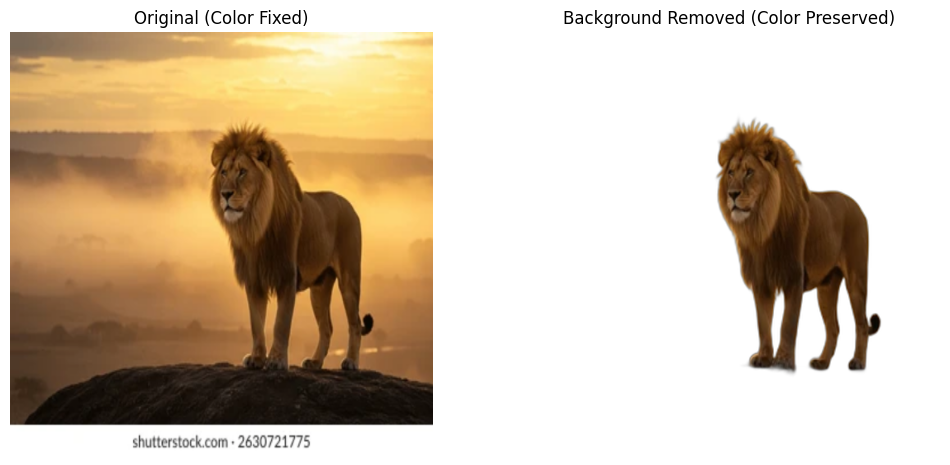

In [16]:
# Open the saved image and remove background
input_img = Image.open("temp_input.png")
output_img = remove(input_img)
output_img.save("output_no_bg.png")

# Load the output for display
output_display = Image.open("output_no_bg.png")

print("✅ Background removed successfully!")

# Display both original and output side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(resized)
ax[0].set_title("Original (Color Fixed)")
ax[0].axis("off")

ax[1].imshow(output_display)
ax[1].set_title("Background Removed (Color Preserved)")
ax[1].axis("off")

plt.show()


In [17]:
from google.colab import files
files.download("output_no_bg.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>